# Day 11: Advanced Pandas - GroupBy, Merge, Pivot & Multi-Table Analysis

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Create Customers Dataset

In [4]:
customers = pd.DataFrame({
    "CustomerID":[1,2,3,4,5,6,7,8,9,10],
    "CustomerName":["John","Alice","Bob","Emma","David","Sophia","Michael","Olivia","James","Charlotte"],
    "City":["New York","Chicago","Boston","Seattle","Dallas","Miami","Denver","Atlanta","Phoenix","San Diego"],
    "Age":[28,32,40,29,35,27,38,31,42,30],
    "Gender":["M","F","M","F","M","F","M","F","M","F"]
})

customers

,CustomerID,CustomerName,City,Age,Gender
0,1,John,New York,28,M
1,2,Alice,Chicago,32,F
2,3,Bob,Boston,40,M
3,4,Emma,Seattle,29,F
4,5,David,Dallas,35,M
5,6,Sophia,Miami,27,F
6,7,Michael,Denver,38,M
7,8,Olivia,Atlanta,31,F
8,9,James,Phoenix,42,M
9,10,Charlotte,San Diego,30,F


## Create Products Dataset

In [5]:
products = pd.DataFrame({
    "ProductID":[101,102,103,104,105,106,107,108,109,110],
    "ProductName":["Laptop","Phone","Headphones","Chair","Table","Desk","Monitor","Keyboard","Mouse","Bookshelf"],
    "Category":["Electronics","Electronics","Electronics","Furniture","Furniture","Furniture","Electronics","Electronics","Electronics","Furniture"],
    "Price":[800,500,100,150,300,250,250,50,30,200]
})

products

,ProductID,ProductName,Category,Price
0,101,Laptop,Electronics,800
1,102,Phone,Electronics,500
2,103,Headphones,Electronics,100
3,104,Chair,Furniture,150
4,105,Table,Furniture,300
5,106,Desk,Furniture,250
6,107,Monitor,Electronics,250
7,108,Keyboard,Electronics,50
8,109,Mouse,Electronics,30
9,110,Bookshelf,Furniture,200


## Create Orders Dataset

In [6]:
orders = pd.DataFrame({
    "OrderID":[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    "CustomerID":[1,2,3,1,4,5,2,3,6,7,8,9,10,4,5,6,7,8,9,10],
    "ProductID":[101,102,104,103,105,102,103,101,107,108,109,110,105,101,106,102,104,107,103,108],
    "Quantity":[1,2,3,2,1,1,3,1,2,4,5,1,2,1,2,1,2,1,4,3],
    "Amount":[800,1000,450,200,300,500,300,800,500,200,150,200,600,800,500,500,300,250,400,150],
    "OrderDate":[
        "2025-01-05","2025-01-06","2025-01-07","2025-01-08",
        "2025-01-09","2025-01-10","2025-01-11","2025-01-12",
        "2025-01-13","2025-01-14","2025-01-15","2025-01-16",
        "2025-01-17","2025-01-18","2025-01-19","2025-01-20",
        "2025-01-21","2025-01-22","2025-01-23","2025-01-24"
    ]
})

orders

,OrderID,CustomerID,ProductID,Quantity,Amount,OrderDate
0,1,1,101,1,800,2025-01-05
1,2,2,102,2,1000,2025-01-06
2,3,3,104,3,450,2025-01-07
3,4,1,103,2,200,2025-01-08
4,5,4,105,1,300,2025-01-09
5,6,5,102,1,500,2025-01-10
6,7,2,103,3,300,2025-01-11
7,8,3,101,1,800,2025-01-12
8,9,6,107,2,500,2025-01-13
9,10,7,108,4,200,2025-01-14


## Dataset Shapes

In [7]:
print("Customers Shape:", customers.shape)
print("Products Shape:", products.shape)
print("Orders Shape:", orders.shape)

Customers Shape: (10, 5)
Products Shape: (10, 4)
Orders Shape: (20, 6)


Head()

In [8]:
customers.head()

,CustomerID,CustomerName,City,Age,Gender
0,1,John,New York,28,M
1,2,Alice,Chicago,32,F
2,3,Bob,Boston,40,M
3,4,Emma,Seattle,29,F
4,5,David,Dallas,35,M


In [9]:
products.head()

,ProductID,ProductName,Category,Price
0,101,Laptop,Electronics,800
1,102,Phone,Electronics,500
2,103,Headphones,Electronics,100
3,104,Chair,Furniture,150
4,105,Table,Furniture,300


In [10]:
orders.head()

,OrderID,CustomerID,ProductID,Quantity,Amount,OrderDate
0,1,1,101,1,800,2025-01-05
1,2,2,102,2,1000,2025-01-06
2,3,3,104,3,450,2025-01-07
3,4,1,103,2,200,2025-01-08
4,5,4,105,1,300,2025-01-09


Info()

In [11]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   CustomerID    10 non-null     int64 
 1   CustomerName  10 non-null     object
 2   City          10 non-null     object
 3   Age           10 non-null     int64 
 4   Gender        10 non-null     object
dtypes: int64(2), object(3)
memory usage: 528.0+ bytes


In [12]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ProductID    10 non-null     int64 
 1   ProductName  10 non-null     object
 2   Category     10 non-null     object
 3   Price        10 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 448.0+ bytes


In [13]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   OrderID     20 non-null     int64 
 1   CustomerID  20 non-null     int64 
 2   ProductID   20 non-null     int64 
 3   Quantity    20 non-null     int64 
 4   Amount      20 non-null     int64 
 5   OrderDate   20 non-null     object
dtypes: int64(5), object(1)
memory usage: 1.1+ KB


Describe()

In [14]:
customers.describe(include="all")

,CustomerID,CustomerName,City,Age,Gender
count,10.00000,10,10,10.000000,10
unique,NaN,10,10,NaN,2
top,NaN,John,New York,NaN,M
freq,NaN,1,1,NaN,5
mean,5.50000,NaN,NaN,33.200000,NaN
std,3.02765,NaN,NaN,5.266245,NaN
min,1.00000,NaN,NaN,27.000000,NaN
25%,3.25000,NaN,NaN,29.250000,NaN
50%,5.50000,NaN,NaN,31.500000,NaN
75%,7.75000,NaN,NaN,37.250000,NaN


In [15]:
products.describe(include="all")

,ProductID,ProductName,Category,Price
count,10.00000,10,10,10.000000
unique,NaN,10,2,NaN
top,NaN,Laptop,Electronics,NaN
freq,NaN,1,6,NaN
mean,105.50000,NaN,NaN,263.000000
std,3.02765,NaN,NaN,233.145162
min,101.00000,NaN,NaN,30.000000
25%,103.25000,NaN,NaN,112.500000
50%,105.50000,NaN,NaN,225.000000
75%,107.75000,NaN,NaN,287.500000


In [16]:
orders.describe(include="all")

,OrderID,CustomerID,ProductID,Quantity,Amount,OrderDate
count,20.00000,20.000000,20.000000,20.000000,20.000000,20
unique,NaN,NaN,NaN,NaN,NaN,20
top,NaN,NaN,NaN,NaN,NaN,2025-01-05
freq,NaN,NaN,NaN,NaN,NaN,1
mean,10.50000,5.500000,104.550000,2.100000,445.000000,NaN
std,5.91608,2.946898,2.837252,1.209611,249.156472,NaN
min,1.00000,1.000000,101.000000,1.000000,150.000000,NaN
25%,5.75000,3.000000,102.000000,1.000000,237.500000,NaN
50%,10.50000,5.500000,104.000000,2.000000,425.000000,NaN
75%,15.25000,8.000000,107.000000,3.000000,525.000000,NaN


Missing Values

In [17]:
customers.isnull().sum()

CustomerID      0
CustomerName    0
City            0
Age             0
Gender          0
dtype: int64

In [18]:
customers.isnull().sum()

CustomerID      0
CustomerName    0
City            0
Age             0
Gender          0
dtype: int64

In [19]:
orders.isnull().sum()

OrderID       0
CustomerID    0
ProductID     0
Quantity      0
Amount        0
OrderDate     0
dtype: int64

Duplicate Values

In [20]:
customers.duplicated().sum()

np.int64(0)

In [21]:
customers.duplicated().sum()

np.int64(0)

In [22]:
customers.duplicated().sum()

np.int64(0)

GroupBy Customer Revenue

In [23]:
orders.groupby("CustomerID")["Amount"].sum()

CustomerID
1     1000
2     1300
3     1250
4     1100
5     1000
6     1000
7      500
8      400
9      600
10     750
Name: Amount, dtype: int64

GroupBy Product Quantity

In [24]:
orders.groupby("ProductID")["Quantity"].sum()

ProductID
101    3
102    4
103    9
104    5
105    3
106    2
107    3
108    7
109    5
110    1
Name: Quantity, dtype: int64

Multiple Column Grouping

In [26]:
orders.groupby(
    ["CustomerID","ProductID"]
)[["Quantity","Amount"]].sum()

Quantity  Amount
CustomerID ProductID                  
1          101               1     800
           103               2     200
2          102               2    1000
           103               3     300
3          101               1     800
           104               3     450
4          101               1     800
           105               1     300
5          102               1     500
           106               2     500
6          102               1     500
           107               2     500
7          104               2     300
           108               4     200
8          107               1     250
           109               5     150
9          103               4     400
           110               1     200
10         105               2     600
           108               3     150

Aggregation Functions

In [27]:
orders.groupby("CustomerID").agg({
    "Amount":["sum","mean","max","min"],
    "Quantity":["sum","mean"]
})

Amount                   Quantity     
              sum   mean   max  min      sum mean
CustomerID                                       
1            1000  500.0   800  200        3  1.5
2            1300  650.0  1000  300        5  2.5
3            1250  625.0   800  450        4  2.0
4            1100  550.0   800  300        2  1.0
5            1000  500.0   500  500        3  1.5
6            1000  500.0   500  500        3  1.5
7             500  250.0   300  200        6  3.0
8             400  200.0   250  150        6  3.0
9             600  300.0   400  200        5  2.5
10            750  375.0   600  150        5  2.5

Transform Method

In [28]:
orders["Customer_Total_Sales"] = (
    orders.groupby("CustomerID")["Amount"]
    .transform("sum")
)

orders.head()

,OrderID,CustomerID,ProductID,Quantity,Amount,OrderDate,Customer_Total_Sales
0,1,1,101,1,800,2025-01-05,1000
1,2,2,102,2,1000,2025-01-06,1300
2,3,3,104,3,450,2025-01-07,1250
3,4,1,103,2,200,2025-01-08,1000
4,5,4,105,1,300,2025-01-09,1100


Filter Groups

In [29]:
orders.groupby("CustomerID").filter(
    lambda x: x["Amount"].sum() > 1000
)

,OrderID,CustomerID,ProductID,Quantity,Amount,OrderDate,Customer_Total_Sales
1,2,2,102,2,1000,2025-01-06,1300
2,3,3,104,3,450,2025-01-07,1250
4,5,4,105,1,300,2025-01-09,1100
6,7,2,103,3,300,2025-01-11,1300
7,8,3,101,1,800,2025-01-12,1250
13,14,4,101,1,800,2025-01-18,1100


Inner Merge

In [30]:
inner_merge = pd.merge(
    orders,
    customers,
    on="CustomerID",
    how="inner"
)

inner_merge.head()

,OrderID,CustomerID,ProductID,Quantity,Amount,OrderDate,Customer_Total_Sales,CustomerName,City,Age,Gender
0,1,1,101,1,800,2025-01-05,1000,John,New York,28,M
1,2,2,102,2,1000,2025-01-06,1300,Alice,Chicago,32,F
2,3,3,104,3,450,2025-01-07,1250,Bob,Boston,40,M
3,4,1,103,2,200,2025-01-08,1000,John,New York,28,M
4,5,4,105,1,300,2025-01-09,1100,Emma,Seattle,29,F


Outer Merge

In [31]:
outer_merge = pd.merge(
    orders,
    customers,
    on="CustomerID",
    how="outer"
)

outer_merge.head()

,OrderID,CustomerID,ProductID,Quantity,Amount,OrderDate,Customer_Total_Sales,CustomerName,City,Age,Gender
0,1,1,101,1,800,2025-01-05,1000,John,New York,28,M
1,4,1,103,2,200,2025-01-08,1000,John,New York,28,M
2,2,2,102,2,1000,2025-01-06,1300,Alice,Chicago,32,F
3,7,2,103,3,300,2025-01-11,1300,Alice,Chicago,32,F
4,3,3,104,3,450,2025-01-07,1250,Bob,Boston,40,M


Multi-Table Merge

In [32]:
merged_df = pd.merge(
    orders,
    customers,
    on="CustomerID"
)

merged_df = pd.merge(
    merged_df,
    products,
    on="ProductID"
)

merged_df.head()

,OrderID,CustomerID,ProductID,Quantity,Amount,OrderDate,Customer_Total_Sales,CustomerName,City,Age,Gender,ProductName,Category,Price
0,1,1,101,1,800,2025-01-05,1000,John,New York,28,M,Laptop,Electronics,800
1,2,2,102,2,1000,2025-01-06,1300,Alice,Chicago,32,F,Phone,Electronics,500
2,3,3,104,3,450,2025-01-07,1250,Bob,Boston,40,M,Chair,Furniture,150
3,4,1,103,2,200,2025-01-08,1000,John,New York,28,M,Headphones,Electronics,100
4,5,4,105,1,300,2025-01-09,1100,Emma,Seattle,29,F,Table,Furniture,300


Pivot Table

In [33]:
pivot_table = pd.pivot_table(
    merged_df,
    values="Amount",
    index="CustomerName",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

pivot_table

Category,Electronics,Furniture
CustomerName,,
Alice,1300,0
Bob,800,450
Charlotte,150,600
David,500,500
Emma,800,300
James,400,200
John,1000,0
Michael,200,300
Olivia,400,0


Category Pivot Summary

In [34]:
pd.pivot_table(
    merged_df,
    values="Amount",
    index="Category",
    aggfunc=["sum","mean","max"]
)

,sum,mean,max
,Amount,Amount,Amount
Category,,,
Electronics,6550,467.857143,1000
Furniture,2350,391.666667,600


Top Customers

In [35]:
merged_df.groupby(
    "CustomerName"
)["Amount"].sum().sort_values(
    ascending=False
)

CustomerName
Alice        1300
Bob          1250
Emma         1100
David        1000
John         1000
Sophia       1000
Charlotte     750
James         600
Michael       500
Olivia        400
Name: Amount, dtype: int64

Revenue by Category

In [37]:
merged_df.groupby(
    "Category"
)["Amount"].sum()

Category
Electronics    6550
Furniture      2350
Name: Amount, dtype: int64

Best Selling Products

In [38]:
merged_df.groupby(
    "ProductName"
)["Quantity"].sum().sort_values(
    ascending=False
)

ProductName
Headphones    9
Keyboard      7
Chair         5
Mouse         5
Phone         4
Laptop        3
Monitor       3
Table         3
Desk          2
Bookshelf     1
Name: Quantity, dtype: int64

Dashboard Metrics

In [36]:
print("Total Revenue:", merged_df["Amount"].sum())

print("Total Customers:",
      merged_df["CustomerID"].nunique())

print("Total Orders:",
      merged_df["OrderID"].nunique())

print("Total Products Sold:",
      merged_df["Quantity"].sum())

Total Revenue: 8900
Total Customers: 10
Total Orders: 20
Total Products Sold: 42


Revenue by Category Chart

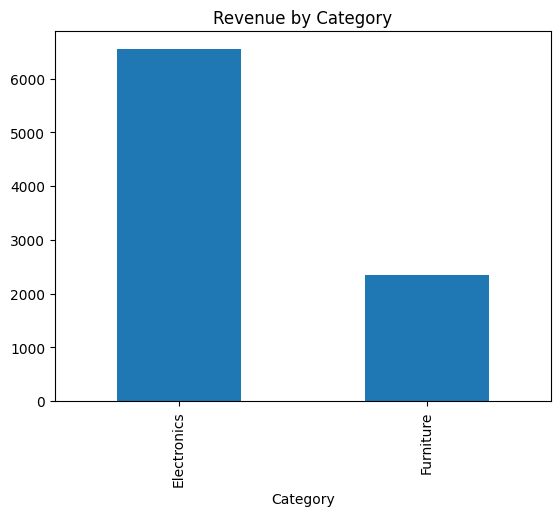

In [40]:
merged_df.groupby(
    "Category"
)["Amount"].sum().plot(kind="bar")

plt.title("Revenue by Category")
plt.show()

Top Customers Chart

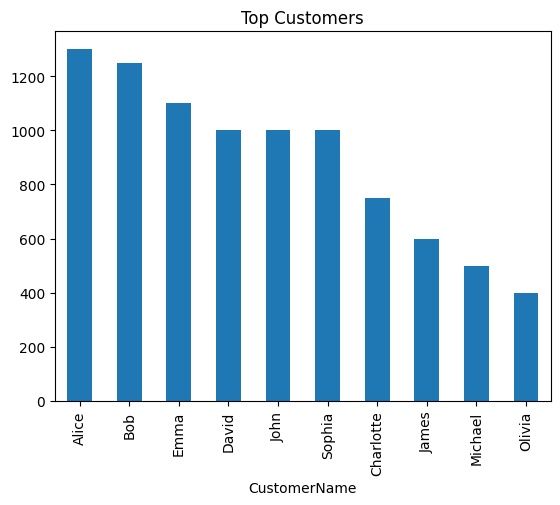

In [42]:
merged_df.groupby(
    "CustomerName"
)["Amount"].sum().nlargest(10).plot(kind="bar")

plt.title("Top Customers")
plt.show()

Best Selling Products Chart

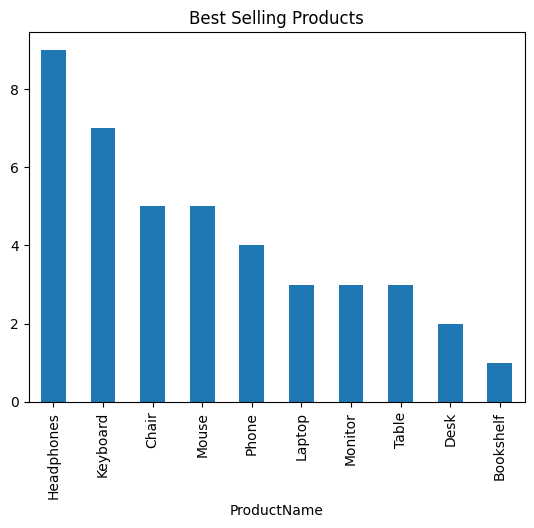

In [43]:
merged_df.groupby(
    "ProductName"
)["Quantity"].sum().nlargest(10).plot(kind="bar")

plt.title("Best Selling Products")
plt.show()

# Conclusion

• Applied GroupBy operations and multiple-column grouping.
• Used aggregation, transform, and filtering methods.
• Performed inner and outer merge operations.
• Created pivot tables for summarized analysis.
• Conducted multi-table business analysis.
• Generated visual insights using charts.